# 3. 予測モデル構築
LightGBM と GPR（ガウス過程回帰）を実装する。

## ライブラリ読み込み

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    WhiteKernel,
    RBF,
    ConstantKernel,
    Matern,
    DotProduct,
)

import lightgbm as lgb

import optuna

## データ読み込み（2.EDA と同じ流れ）

In [2]:
# 入力：読み込みたい記述子のタイプを選択
descriptor_type = "mordred_3d"  # 'rdkit' or 'mordred_2d' or 'mordred_3d' or 'fp'

dataset = pd.read_csv("../data/dataset_train.csv", index_col=0)
target = dataset[["Emission max (nm)", "Quantum yield"]]

if descriptor_type == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
elif descriptor_type == "mordred_2d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0
    )
elif descriptor_type == "mordred_3d":
    des = pd.read_csv(
        "outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0
    )
elif descriptor_type == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の descriptor_type: {descriptor_type}")

# 目的変数と記述子を結合
dataset_train = target.join(des, how="inner")
print(target.shape, des.shape, dataset_train.shape)

(13132, 2) (13132, 1382) (13132, 1384)


In [3]:
# データを1000個程度に絞る（GPR は計算量が O(n^3) 級のため件数を制限）
MAX_SAMPLES = 500
RANDOM_STATE = 1234

if len(dataset_train) > MAX_SAMPLES:
    dataset_train = dataset_train.sample(n=MAX_SAMPLES, random_state=RANDOM_STATE)
    print(f"dataset_train を {MAX_SAMPLES} 件に間引き: {dataset_train.shape}")
else:
    print(f"件数 ≤ {MAX_SAMPLES} のためそのまま利用: {dataset_train.shape}")

dataset_train を 500 件に間引き: (500, 1384)


### 可視化関数定義
spearmanrの相関係数追加

In [4]:
from scipy.stats import spearmanr

def yyplot(train_df, test_df):
    # ===== 指標の計算 =====
    rmse_tr = np.sqrt(mean_squared_error(train_df['true'], train_df['pred']))
    r2_tr = r2_score(train_df['true'], train_df['pred'])
    mae_tr = mean_absolute_error(train_df['true'], train_df['pred'])
    spearman_tr = spearmanr(train_df['true'], train_df['pred']).statistic

    rmse_te = np.sqrt(mean_squared_error(test_df['true'], test_df['pred']))
    r2_te = r2_score(test_df['true'], test_df['pred'])
    mae_te = mean_absolute_error(test_df['true'], test_df['pred'])
    spearman_te = spearmanr(test_df['true'], test_df['pred']).correlation

    # ===== グラフ作成 =====
    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111)

    # 散布図
    ax.scatter(train_df['true'], train_df['pred'], c='red', label='Train', alpha=0.6)
    ax.scatter(test_df['true'], test_df['pred'], c='blue', label='Val', alpha=0.6)

    # 理想線
    all_true = pd.concat([train_df['true'], test_df['true']])
    min_val = all_true.min()
    max_val = all_true.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'k--')

    # 軸ラベル
    ax.set_xlabel('True Value')
    ax.set_ylabel('Predicted Value')

    # 範囲調整
    margin = (max_val - min_val) * 0.05
    ax.set_xlim(min_val - margin, max_val + margin)
    ax.set_ylim(min_val - margin, max_val + margin)

    # 評価値表示（右上）
    ax.text(0.05, 0.95, f'Train RMSE = {rmse_tr:.2f}\nTrain MAE  = {mae_tr:.2f}\nTrain R²    = {r2_tr:.2f}\nTrain Spearman = {spearman_tr:.2f}',
            transform=ax.transAxes, fontsize=11, color='red', verticalalignment='top')
    ax.text(0.05, 0.80, f'Val  RMSE = {rmse_te:.2f}\nVal  MAE  = {mae_te:.2f}\nVal  R²    = {r2_te:.2f}\nVal  Spearman = {spearman_te:.2f}',
            transform=ax.transAxes, fontsize=11, color='blue', verticalalignment='top')

    # 凡例
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## Emission予測モデル

In [5]:
# 目的変数と説明変数
y = dataset_train["Emission max (nm)"]
X = dataset_train.drop("Emission max (nm)", axis=1)
X = X.drop("Quantum yield", axis=1)

# 学習 / 検証（ホールドアウト）
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1234
)

# # 標準偏差 0 の特徴量を除外（sample_program と同様）
# zero_std_cols = X_train.columns[X_train.std() == 0]
# if len(zero_std_cols) > 0:
#     X_train = X_train.drop(zero_std_cols, axis=1)
#     X_val = X_val.drop(zero_std_cols, axis=1)

print("X_train:", X_train.shape, "X_val:", X_val.shape)

X_train: (350, 1382) X_val: (150, 1382)


In [6]:
# オートスケーリング（学習データの統計量で fit）
X_scaler = StandardScaler()
autoscaled_X_train = pd.DataFrame(
    X_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
autoscaled_X_val = pd.DataFrame(
    X_scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
)

y_scaler = StandardScaler()
autoscaled_y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
autoscaled_y_val = y_scaler.transform(y_val.values.reshape(-1, 1))

autoscaled_y_train = pd.DataFrame(
    autoscaled_y_train, index=y_train.index, columns=["y"]
)
autoscaled_y_val = pd.DataFrame(
    autoscaled_y_val, index=y_val.index, columns=["y"]
)

### LightGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127619
[LightGBM] [Info] Number of data points in the train set: 350, number of used features: 1259
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

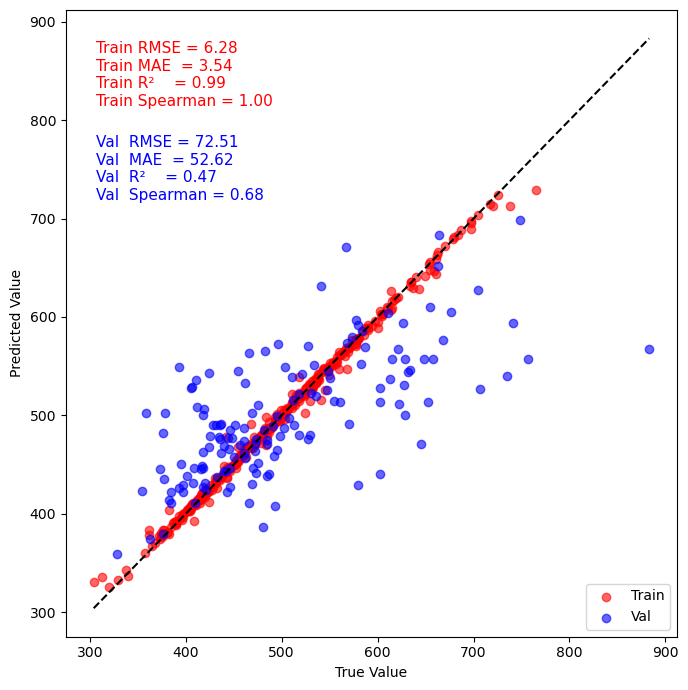

In [7]:
# デフォルト
model_lgb = lgb.LGBMRegressor(random_state=1234)

# モデル学習
model_lgb.fit(autoscaled_X_train, autoscaled_y_train, eval_set = [(autoscaled_X_val, autoscaled_y_val)])

# 予測
y_train_pred_scaled = model_lgb.predict(autoscaled_X_train)
y_val_pred_scaled = model_lgb.predict(autoscaled_X_val)

# 元のスケールに逆変換（reshapeが必要）
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1))

# 可視化用データフレーム作成
train_df = pd.DataFrame({
    'true': y_train.reset_index(drop=True),
    'pred': y_train_pred.flatten()
})
val_df = pd.DataFrame({
    'true': y_val.reset_index(drop=True),
    'pred': y_val_pred.flatten()
})

# 可視化
yyplot(train_df, val_df)

### GPR：カーネル選択（sample_program_03_11_gpr_kenrnels.py ベース）
データ点数が多いと計算量・メモリが大きい（$O(n^3)$）。必要なら学習データを間引くか `fold_number` を小さくする。

In [8]:
n_features = autoscaled_X_train.shape[1]

kernels = [
    ConstantKernel() * DotProduct() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * RBF(np.ones(n_features)) + WhiteKernel(),
    ConstantKernel() * RBF(np.ones(n_features))
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=1.5)
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=0.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=0.5)
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=2.5)
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
]

fold_number = 3  # 5から3に削減

cross_validation = KFold(n_splits=fold_number, random_state=9, shuffle=True)

X_tr = autoscaled_X_train.values
y_tr_scaled = autoscaled_y_train["y"].values

r2cvs = []
for index, kernel in enumerate(kernels):
    print(index + 1, "/", len(kernels))
    # n_restarts_optimizer=0でハイパーパラメータ最適化を無効化、normalize_y=Trueで数値安定性向上
    model_cv = GaussianProcessRegressor(
        alpha=1e-10,
        kernel=kernel,
        random_state=0,
        n_restarts_optimizer=0,
        normalize_y=True
    )
    estimated_y_in_cv = np.ndarray.flatten(
        cross_val_predict(model_cv, X_tr, y_tr_scaled, cv=cross_validation)
    )
    estimated_y_in_cv = y_scaler.inverse_transform(estimated_y_in_cv.reshape(-1, 1)).ravel()
    r2cvs.append(r2_score(y_train, estimated_y_in_cv))

optimal_kernel_number = int(np.argmax(r2cvs))
optimal_kernel = kernels[optimal_kernel_number]
print("クロスバリデーションで選択されたカーネル関数の番号 :", optimal_kernel_number)
print("クロスバリデーションで選択されたカーネル関数 :", optimal_kernel)

model = GaussianProcessRegressor(
    alpha=1e-10,
    kernel=optimal_kernel,
    random_state=0,
    n_restarts_optimizer=0,
    normalize_y=True
)
model.fit(X_tr, y_tr_scaled)

1 / 11
2 / 11
3 / 11
4 / 11


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 785 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 793 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 795 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/

5 / 11


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 780 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 785 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 795 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warn

6 / 11
7 / 11
8 / 11
9 / 11
10 / 11
11 / 11
クロスバリデーションで選択されたカーネル関数の番号 : 7
クロスバリデーションで選択されたカーネル関数 : 1**2 * Matern(length_scale=1, nu=0.5) + WhiteKernel(noise_level=1)


,kernel,1**2 * Matern...noise_level=1)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,0
,kernel__k1,"1**2 * Matern...ale=1, nu=0.5)"
,kernel__k2,WhiteKernel(noise_level=1)
,kernel__k1__k1,1**2


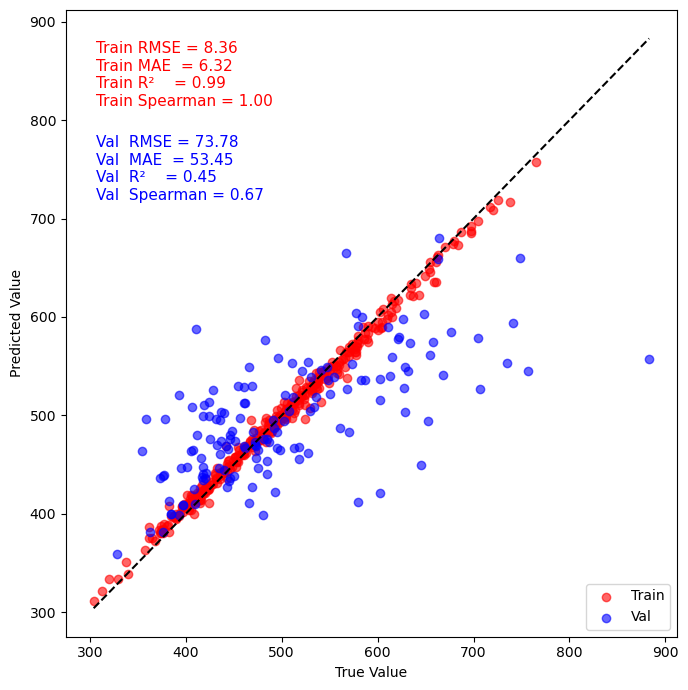

In [9]:
# 予測、yyplot
pred_train_s, _ = model.predict(autoscaled_X_train.values, return_std=True)
pred_val_s, _ = model.predict(autoscaled_X_val.values, return_std=True)

pred_train = y_scaler.inverse_transform(pred_train_s.reshape(-1, 1)).ravel()
pred_val = y_scaler.inverse_transform(pred_val_s.reshape(-1, 1)).ravel()

train_df = pd.DataFrame({"true": y_train.values, "pred": pred_train}, index=y_train.index)
test_df = pd.DataFrame({"true": y_val.values, "pred": pred_val}, index=y_val.index)

yyplot(train_df, test_df)

## Quantum yield予測モデル

In [10]:
# 目的変数と説明変数
y = dataset_train["Quantum yield"]
X = dataset_train.drop("Quantum yield", axis=1)
X = X.drop("Emission max (nm)", axis=1)

# 学習 / 検証（ホールドアウト）
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1234
)

# # 標準偏差 0 の特徴量を除外（sample_program と同様）
# zero_std_cols = X_train.columns[X_train.std() == 0]
# if len(zero_std_cols) > 0:
#     X_train = X_train.drop(zero_std_cols, axis=1)
#     X_val = X_val.drop(zero_std_cols, axis=1)

print("X_train:", X_train.shape, "X_val:", X_val.shape)

X_train: (350, 1382) X_val: (150, 1382)


In [11]:
# オートスケーリング（学習データの統計量で fit）
X_scaler = StandardScaler()
autoscaled_X_train = pd.DataFrame(
    X_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
autoscaled_X_val = pd.DataFrame(
    X_scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
)

y_scaler = StandardScaler()
autoscaled_y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
autoscaled_y_val = y_scaler.transform(y_val.values.reshape(-1, 1))

autoscaled_y_train = pd.DataFrame(
    autoscaled_y_train, index=y_train.index, columns=["y"]
)
autoscaled_y_val = pd.DataFrame(
    autoscaled_y_val, index=y_val.index, columns=["y"]
)

### LightGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021696 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127619
[LightGBM] [Info] Number of data points in the train set: 350, number of used features: 1259
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

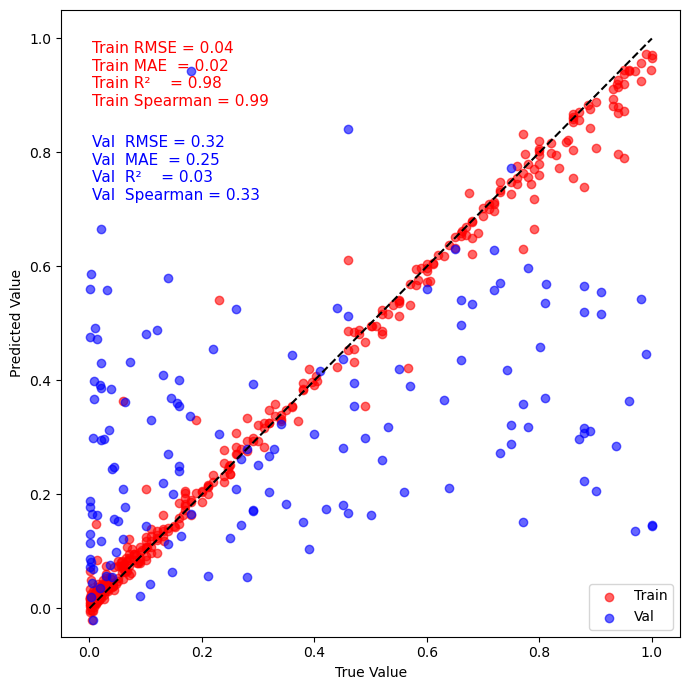

In [12]:
# デフォルト
model_lgb = lgb.LGBMRegressor(random_state=1234)

# モデル学習
model_lgb.fit(autoscaled_X_train, autoscaled_y_train, eval_set = [(autoscaled_X_val, autoscaled_y_val)])

# 予測
y_train_pred_scaled = model_lgb.predict(autoscaled_X_train)
y_val_pred_scaled = model_lgb.predict(autoscaled_X_val)

# 元のスケールに逆変換（reshapeが必要）
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1))

# 可視化用データフレーム作成
train_df = pd.DataFrame({
    'true': y_train.reset_index(drop=True),
    'pred': y_train_pred.flatten()
})
val_df = pd.DataFrame({
    'true': y_val.reset_index(drop=True),
    'pred': y_val_pred.flatten()
})

# 可視化
yyplot(train_df, val_df)

### LightGBM + optuna

In [13]:
def objective_lgb(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',  # LightGBMが内部で使う評価指標
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_data_in_leaf' : trial.suggest_int('min_data_in_leaf', 1, 10),
        'min_child_samples' :trial.suggest_int('min_child_samples', 1, 10),
        'random_state': 42,
        'verbosity': -1,
    }

    model = lgb.LGBMRegressor(**param)

    # 学習&予測
    model.fit(autoscaled_X_train, autoscaled_y_train, eval_set=[(autoscaled_X_val, autoscaled_y_val)])
    y_pred_scaled = model.predict(autoscaled_X_val)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

    # 汎化性能算出
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    return rmse

In [14]:
# 最適化
study = optuna.create_study(direction='minimize')
study.optimize(objective_lgb, n_trials=10, timeout=600)  # 50試行 or 600秒

# 結果表示
print("Best trial:")
print(f"  RMSE: {study.best_trial.value:.4f}")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-04-24 07:57:44,170] A new study created in memory with name: no-name-e3b2b61c-5c14-4fc4-a060-4565d130572e
[I 2026-04-24 07:57:46,496] Trial 0 finished with value: 0.3088383281515781 and parameters: {'n_estimators': 290, 'learning_rate': 0.012047808950948346, 'max_depth': 7, 'num_leaves': 96, 'subsample': 0.8895793756042765, 'colsample_bytree': 0.6012874289468857, 'reg_alpha': 0.8530707751367351, 'reg_lambda': 0.0009971614662037183, 'min_data_in_leaf': 4, 'min_child_samples': 3}. Best is trial 0 with value: 0.3088383281515781.
[I 2026-04-24 07:57:47,996] Trial 1 finished with value: 0.3130503842491582 and parameters: {'n_estimators': 171, 'learning_rate': 0.07558719480087993, 'max_depth': 9, 'num_leaves': 93, 'subsample': 0.7532531378609977, 'colsample_bytree': 0.7118433838937878, 'reg_alpha': 0.01856723650295243, 'reg_lambda': 6.9629719991143535e-06, 'min_data_in_leaf': 6, 'min_child_samples': 7}. Best is trial 0 with value: 0.3088383281515781.
[I 2026-04-24 07:57:48,919] Trial

Best trial:
  RMSE: 0.3074
    n_estimators: 52
    learning_rate: 0.11436105783889808
    max_depth: 4
    num_leaves: 19
    subsample: 0.7483777237729505
    colsample_bytree: 0.9177385240867817
    reg_alpha: 2.1729964075861193e-06
    reg_lambda: 0.005678310716855576
    min_data_in_leaf: 1
    min_child_samples: 10


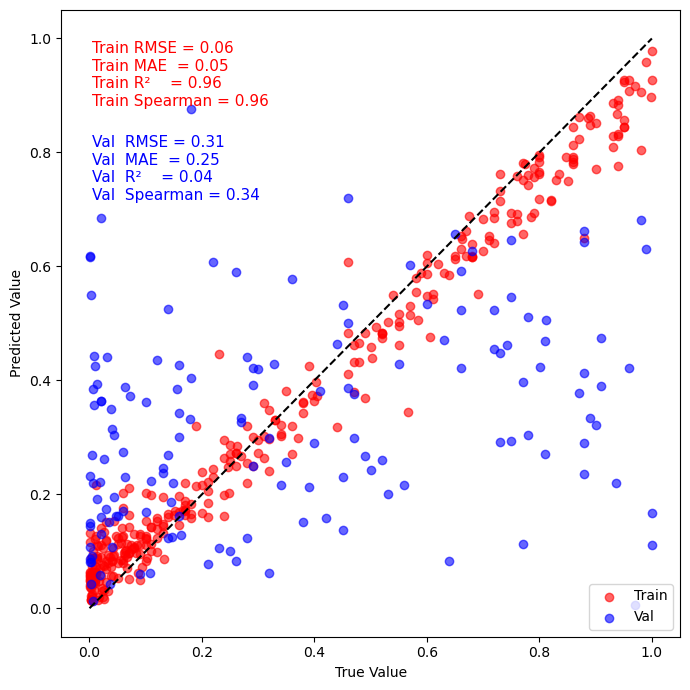

In [15]:
# モデル再構築
best_params = study.best_trial.params

model_lgb_optuna = lgb.LGBMRegressor(**best_params)
model_lgb_optuna.fit(autoscaled_X_train, autoscaled_y_train)

# 予測
y_train_pred_scaled = model_lgb_optuna.predict(autoscaled_X_train)
y_val_pred_scaled = model_lgb_optuna.predict(autoscaled_X_val)

# 元のスケールに逆変換（reshapeが必要）
y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1))

# 可視化用データフレーム作成
train_df = pd.DataFrame({
    'true': y_train.reset_index(drop=True),
    'pred': y_train_pred.flatten()
})
val_df = pd.DataFrame({
    'true': y_val.reset_index(drop=True),
    'pred': y_val_pred.flatten()
})

# 可視化
yyplot(train_df, val_df)

### GPR：カーネル選択（sample_program_03_11_gpr_kenrnels.py ベース）
データ点数が多いと計算量・メモリが大きい（$O(n^3)$）。必要なら学習データを間引くか `fold_number` を小さくする。

In [16]:
n_features = autoscaled_X_train.shape[1]

kernels = [
    ConstantKernel() * DotProduct() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel(),
    ConstantKernel() * RBF() + WhiteKernel() + ConstantKernel() * DotProduct(),
    ConstantKernel() * RBF(np.ones(n_features)) + WhiteKernel(),
    ConstantKernel() * RBF(np.ones(n_features))
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=1.5)
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=0.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=0.5)
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
    ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
    ConstantKernel() * Matern(nu=2.5)
    + WhiteKernel()
    + ConstantKernel() * DotProduct(),
]

fold_number = 3  # 5から3に削減

cross_validation = KFold(n_splits=fold_number, random_state=9, shuffle=True)

X_tr = autoscaled_X_train.values
y_tr_scaled = autoscaled_y_train["y"].values

r2cvs = []
for index, kernel in enumerate(kernels):
    print(index + 1, "/", len(kernels))
    # n_restarts_optimizer=0でハイパーパラメータ最適化を無効化、normalize_y=Trueで数値安定性向上
    model_cv = GaussianProcessRegressor(
        alpha=1e-10,
        kernel=kernel,
        random_state=0,
        n_restarts_optimizer=0,
        normalize_y=True
    )
    estimated_y_in_cv = np.ndarray.flatten(
        cross_val_predict(model_cv, X_tr, y_tr_scaled, cv=cross_validation)
    )
    estimated_y_in_cv = y_scaler.inverse_transform(estimated_y_in_cv.reshape(-1, 1)).ravel()
    r2cvs.append(r2_score(y_train, estimated_y_in_cv))

optimal_kernel_number = int(np.argmax(r2cvs))
optimal_kernel = kernels[optimal_kernel_number]
print("クロスバリデーションで選択されたカーネル関数の番号 :", optimal_kernel_number)
print("クロスバリデーションで選択されたカーネル関数 :", optimal_kernel)

model = GaussianProcessRegressor(
    alpha=1e-10,
    kernel=optimal_kernel,
    random_state=0,
    n_restarts_optimizer=0,
    normalize_y=True
)
model.fit(X_tr, y_tr_scaled)

1 / 11
2 / 11


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


3 / 11
4 / 11


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 246 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 248 of parameter k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/ho

5 / 11


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 203 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 212 of parameter k1__k1__k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnin

6 / 11
7 / 11
8 / 11
9 / 11


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


10 / 11


/home/kawano/miniforge3/envs/chem/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


11 / 11
クロスバリデーションで選択されたカーネル関数の番号 : 8
クロスバリデーションで選択されたカーネル関数 : 1**2 * Matern(length_scale=1, nu=0.5) + WhiteKernel(noise_level=1) + 1**2 * DotProduct(sigma_0=1)


,kernel,1**2 * Matern...uct(sigma_0=1)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,0
,kernel__k1,1**2 * Matern...noise_level=1)
,kernel__k2,1**2 * DotProduct(sigma_0=1)
,kernel__k1__k1,"1**2 * Matern...ale=1, nu=0.5)"


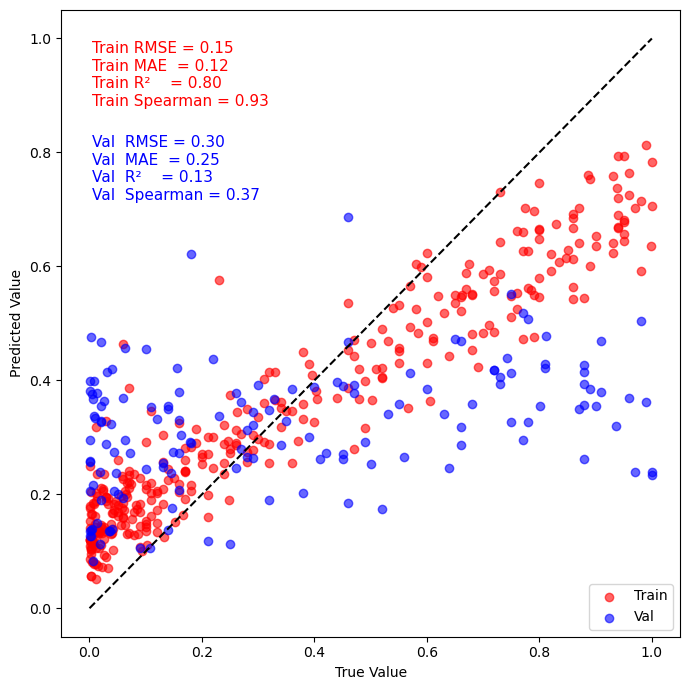

In [17]:
# 予測、yyplot
pred_train_s, _ = model.predict(autoscaled_X_train.values, return_std=True)
pred_val_s, _ = model.predict(autoscaled_X_val.values, return_std=True)

pred_train = y_scaler.inverse_transform(pred_train_s.reshape(-1, 1)).ravel()
pred_val = y_scaler.inverse_transform(pred_val_s.reshape(-1, 1)).ravel()

train_df = pd.DataFrame({"true": y_train.values, "pred": pred_train}, index=y_train.index)
test_df = pd.DataFrame({"true": y_val.values, "pred": pred_val}, index=y_val.index)

yyplot(train_df, test_df)